# Project: BBL AI Fantasy v2 
# Section: Pricing Model Build

# 0. Prerequistes

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
from statsmodels.api import OLS

os.getcwd()
directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2'
directory

'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2'

# 1. Data Extraction

In [2]:
# BBL14 player price (each round)
# Round 1
price_1 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_1/player_price.csv'), low_memory=False)[['player', 'Price']]
#price_1 = price_1.rename(columns={'Price': 'Price_1'})
price_1['rnd'] = 1

# Round 2
price_2 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_2/player_price_round_2.csv'), low_memory=False)[['player', 'Price']]
#price_2 = price_2.rename(columns={'Price': 'Price_2'})
price_2['rnd'] = 2

# Round 3
price_3 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_3/player_price_rnd_3.csv'), low_memory=False)[['player', 'Price']]
#price_3 = price_3.rename(columns={'Price': 'Price_3'})
price_3['rnd'] = 3

# Round 4
price_4 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_4/player_price_rnd_4.csv'), low_memory=False)[['player', 'Price']]
#price_4 = price_4.rename(columns={'Price': 'Price_4'})
price_4['rnd'] = 4

# Round 5
price_5 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_5/player_price_rnd_5.csv'), low_memory=False)[['player', 'Price']]
#price_5 = price_5.rename(columns={'Price': 'Price_5'})
price_5['rnd'] = 5

# Round 6
price_6 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_6/player_price_rnd_6.csv'), low_memory=False)[['player', 'Price']]
#price_6 = price_6.rename(columns={'Price': 'Price_6'})
price_6['rnd'] = 6

# Round 7
price_7 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_7/player_price_rnd_7.csv'), low_memory=False)[['player', 'Price']]
#price_7 = price_7.rename(columns={'Price': 'Price_7'})
price_7['rnd'] = 7

# Round 8
price_8 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_8/player_price_rnd_8.csv'), low_memory=False)[['player', 'Price']]
#price_8 = price_8.rename(columns={'Price': 'Price_8'})
price_8['rnd'] = 8

# Round 9
price_9 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/round_9/player_price_rnd_9.csv'), low_memory=False)[['player', 'Price']]
#price_9 = price_9.rename(columns={'Price': 'Price_9'})
price_9['rnd'] = 9
print(price_9)

# After Round 9
price_10 = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/end_of_round_9/player_price_final.csv'), low_memory=False)[['player', 'Price']]
#price_10 = price_10.rename(columns={'Price': 'Price_10'})
price_10['rnd'] = 10
print(price_10)

               player   Price  rnd
0             A Zampa  124300    9
1             AC Agar  156600    9
2            AF Milne  102600    9
3             AI Ross  123900    9
4           AJ Hosein  125500    9
..                ...     ...  ...
144           WA Agar  122500    9
145  Waqar Salamkheil   92200    9
146     Will Salzmann   39500    9
147      Xavier Crone   39500    9
148       XC Bartlett  140100    9

[149 rows x 3 columns]
            player   Price  rnd
0        SA Abbott  150800   10
1          AC Agar  156400   10
2          WA Agar  122500   10
3     Fabian Allen  115700   10
4       Finn Allen  111900   10
..             ...     ...  ...
144       JW Wells   84400   10
145  JD Wildermuth   58500   10
146        JP Wood   73800   10
147       M Wright  126300   10
148        A Zampa  124300   10

[149 rows x 3 columns]


In [3]:
# BBL14 player points
point = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/end_of_round_9/player_bbl14_pts_final_2425.csv'), low_memory=False)
point.drop(['Price'], axis=1, inplace=True)

In [4]:
# BBL14 Team Fixture
fix_df = pd.read_csv(os.path.join(directory,'data/prev_season_data/add_data_created/overall/team_fixture.csv'), low_memory=False)

# 2. Data Manipulation

In [5]:
# Create Response Variable Table
# Player | Round | Price Delta (Price - Price_rnd-1)
price = pd.concat([price_1,
                  price_2,
                  price_3,
                  price_4,
                  price_5,
                  price_6,
                  price_7,
                  price_8,
                  price_9,
                  price_10])

# price delta loop
price_delta = pd.DataFrame(columns=['player', 'rnd', 'price_delta'])

for i in range(2,11):
    # previous price and current price
    price_pre = price[price['rnd'] == i-1].rename(columns={'Price': 'price_pre'})
    price_curr = price[price['rnd'] == i].rename(columns={'Price': 'price_curr', 'rnd': 'rnd_curr'})

    # join price table and calculate delta
    price_temp = pd.merge(price_pre, price_curr, how = 'left', on = 'player')
    price_temp['price_delta'] = price_temp['price_curr'] - price_temp['price_pre']
    price_temp['price_delta'] = price_temp['price_delta'].astype(float)
    price_temp.drop(columns=['rnd_curr'],axis=1, inplace=True)

    price_delta = pd.concat([price_delta, price_temp])

price_delta

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\2667553995.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  price_delta = pd.concat([price_delta, price_temp])


,player,rnd,price_delta,price_pre,price_curr
0,SA Abbott,1,3900.0,131800.0,135700.0
1,AC Agar,1,-600.0,124100.0,123500.0
2,WA Agar,1,0.0,99700.0,99700.0
3,Finn Allen,1,-11300.0,152000.0,140700.0
4,Fabian Allen,1,-1800.0,117500.0,115700.0
...,...,...,...,...,...
144,WA Agar,9,0.0,122500.0,122500.0
145,Waqar Salamkheil,9,0.0,92200.0,92200.0
146,Will Salzmann,9,0.0,39500.0,39500.0
147,Xavier Crone,9,0.0,39500.0,39500.0


In [6]:
# Game to Round Team Lookup Table
fix_df.fillna(0, inplace=True)
fix_col_list = fix_df.columns.drop(['Team'])

# Create binary columns based on missing values
for col in fix_col_list:
    fix_df[col] = np.where(fix_df[col] == 0, 0, 1)

# Change table from wide to long
rnd_game_df = pd.melt(fix_df, id_vars = 'Team',
                      var_name='rnd', value_name='games')
rnd_game_df['rnd'] = rnd_game_df['rnd'].str[1:2]
rnd_game_df = rnd_game_df.groupby(['Team', 'rnd'])['games'].sum().reset_index()
rnd_game_df['cum_games'] = rnd_game_df.groupby(['Team'])['games'].cumsum()
rnd_game_df.drop(['games'], axis=1, inplace=True)
rnd_game_df.rename(columns={'cum_games':'games'}, inplace=True)
rnd_game_df.sort_values(['rnd','games'], inplace=True)

# Create team games df
total_games = pd.DataFrame(list(range(1,11)))
total_games.rename(columns={total_games.columns[0]:'games'}, inplace=True)
total_games['join'] = 1

teams = pd.DataFrame(fix_df['Team']).copy()
teams['join'] = 1

game_rnd_df = pd.merge(teams, total_games, on = 'join').drop(['join'], axis=1)

# Join round to game table (using fuzzy join)
game_rnd_team_df = pd.merge_asof(game_rnd_df.sort_values('games'), rnd_game_df.sort_values('games'), on = 'games', by='Team', direction='forward')
game_rnd_team_df

,Team,games,rnd
0,Adelaide Strikers,1,1
1,Melbourne Stars,1,1
2,Brisbane Heat,1,1
3,Sydney Sixers,1,1
4,Sydney Thunder,1,1
...,...,...,...
75,Sydney Sixers,10,9
76,Melbourne Stars,10,9
77,Adelaide Strikers,10,9
78,Hobart Hurricanes,10,9


In [7]:
# Add round column to player points table
# Change table from wide to long
pts_game_df = pd.melt(point, id_vars = ['player','Team'],
                      var_name='games', value_name='points')
pts_game_df['games'] = pts_game_df['games'].str[5:7].astype('Int64')

pts_rnd_game_df = pd.merge(pts_game_df, game_rnd_team_df, on=['Team', 'games'])

pts_rnd_game_df

,player,Team,games,points,rnd
0,MW Short,Adelaide Strikers,1,41.0,1
1,SPD Smith,Sydney Sixers,1,NaN,1
2,GJ Maxwell,Melbourne Stars,1,NaN,1
3,W Sutherland,Melbourne Renegades,1,99.0,1
4,DA Warner,Sydney Thunder,1,17.0,1
...,...,...,...,...,...
1485,Mahli Beardman,Perth Scorchers,10,103.0,9
1486,TF Rogers,Melbourne Stars,10,9.0,9
1487,Will Salzmann,Sydney Thunder,10,NaN,9
1488,Xavier Crone,Melbourne Renegades,10,NaN,9


In [8]:
# Points per round table
pts_per_rnd = pts_rnd_game_df.dropna().groupby(['player', 'rnd'])['points'].sum().reset_index()
print(pts_per_rnd)

# Points per game table
pts_per_game = pts_rnd_game_df.dropna().groupby(['player', 'games'])['points'].sum().reset_index()
print(pts_per_game)

           player rnd  points
0         A Zampa   1    36.0
1         A Zampa   2    34.0
2         A Zampa   4   103.0
3         A Zampa   5     4.0
4         A Zampa   6    87.0
..            ...  ..     ...
696   XC Bartlett   6    25.0
697   XC Bartlett   7    14.0
698   XC Bartlett   8    26.0
699   XC Bartlett   9    37.0
700  Xavier Crone   5     1.0

[701 rows x 3 columns]
           player  games  points
0         A Zampa      1     8.0
1         A Zampa      2    28.0
2         A Zampa      3    34.0
3         A Zampa      4    43.0
4         A Zampa      5    60.0
..            ...    ...     ...
792   XC Bartlett      7    25.0
793   XC Bartlett      8    14.0
794   XC Bartlett      9    26.0
795   XC Bartlett     10    37.0
796  Xavier Crone      6     1.0

[797 rows x 3 columns]


# Feature Creation

In [9]:
# # Points per Round Features

# # Loop through all BBL14 players

# # Create empty dataframe to hold fantasy point outputs from the for loop
# bbl14_rnd_pts_table = pd.DataFrame()
# bbl14_rnd_pts_table["player"] = []
# bbl14_rnd_pts_table["rnd"] = []
# bbl14_rnd_pts_table["curr_rnd_pts"] = []
# bbl14_rnd_pts_table["prev_rnd_pts"] = []
# bbl14_rnd_pts_table["two_prev_rnd_pts"] = []
# bbl14_rnd_pts_table["last_2_rnd_ma_pts"] = []
# bbl14_rnd_pts_table["last_3_rnd_ma_pts"] = []
# bbl14_rnd_pts_table["seas_avg_rnd_pts"] = []

# # List of all the unique players in the bbl14 season    
# bbl14_play_list = pts_per_rnd['player'].unique()

# # For loop for all BBL players in bbl14 season
# for j in bbl14_play_list:
#     full_play_pts_df = pts_per_rnd[pts_per_rnd['player'] == j]
#     full_play_pts_df = full_play_pts_df.sort_values(by = ['rnd'])
#     full_play_pts_df['rnd_cnt'] = np.arange(len(full_play_pts_df)) + 1  

#     # List of all the rounds played by individual    
#     rnd_num_list = full_play_pts_df['rnd_cnt'].unique()

#     # For loop for all individual rounds by player
#     for k in rnd_num_list:
#         # Current Round
#         curr_rnd_play_pts_feat_df = full_play_pts_df[full_play_pts_df['rnd_cnt'] == k].rename(columns={"points":"curr_rnd_pts"}).drop(columns=["rnd_cnt"], axis = 1)

#         # prior round points
#         prior_rnd_play_pts_df = full_play_pts_df[full_play_pts_df['rnd_cnt'] == k - 1].rename(columns={"points":"prev_rnd_pts"})
#         prior_rnd_play_pts_df = prior_rnd_play_pts_df.drop(columns=["rnd", "rnd_cnt"], axis = 1)
#         curr_rnd_play_pts_feat_df = pd.merge(curr_rnd_play_pts_feat_df, prior_rnd_play_pts_df, left_on = ["player"], right_on = ["player"], how = "left")

#         # two prior round points
#         two_prior_rnd_play_pts_df = full_play_pts_df[full_play_pts_df['rnd_cnt'] == k - 2].rename(columns={"points":"two_prev_rnd_pts"})
#         two_prior_rnd_play_pts_df = two_prior_rnd_play_pts_df.drop(columns=["rnd", "rnd_cnt"], axis = 1)
#         curr_rnd_play_pts_feat_df = pd.merge(curr_rnd_play_pts_feat_df, two_prior_rnd_play_pts_df, left_on = ["player"], right_on = ["player"], how = "left")

#         # Last two rounds moving average
#         if k >= 2:
#             ma_2_rnd_play_pts_df = full_play_pts_df[(full_play_pts_df['rnd_cnt'] <= k) & (full_play_pts_df['rnd_cnt'] >= k - 1)]
#             ma_2_rnd_play_pts_df = ma_2_rnd_play_pts_df.drop(columns=["rnd", "rnd_cnt"], axis = 1)
#             ma_2_rnd_play_pts_df_agg = ma_2_rnd_play_pts_df.groupby(["player"], as_index=False).agg(
#             last_2_rnd_ma_pts = ('points', "mean"),
#             )

#         else:
#             ma_2_rnd_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['rnd_cnt'] == k)]
#             ma_2_rnd_play_pts_df_agg = ma_2_rnd_play_pts_df_agg.drop(columns=["rnd", "rnd_cnt", "points"], axis = 1)
#             ma_2_rnd_play_pts_df_agg['last_2_rnd_ma_pts'] = np.nan
                                                        
#         curr_rnd_play_pts_feat_df = pd.merge(curr_rnd_play_pts_feat_df, ma_2_rnd_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

#         # Prior 3 Games in the season aggregate attributes
#         if k >= 3:
#             ma_3_rnd_play_pts_df = full_play_pts_df[(full_play_pts_df['rnd_cnt'] <= k) & (full_play_pts_df['rnd_cnt'] >= k - 2)]
#             ma_3_rnd_play_pts_df = ma_3_rnd_play_pts_df.drop(columns=["rnd", "rnd_cnt"], axis = 1)
#             ma_3_rnd_play_pts_df_agg = ma_3_rnd_play_pts_df.groupby(["player"], as_index=False).agg(
#             last_3_rnd_ma_pts = ('points', "mean"),
#             )

#         else:
#             ma_3_rnd_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['rnd_cnt'] == k)]
#             ma_3_rnd_play_pts_df_agg = ma_3_rnd_play_pts_df_agg.drop(columns=["rnd", "rnd_cnt","points"], axis = 1)
#             ma_3_rnd_play_pts_df_agg['last_3_rnd_ma_pts'] = np.nan

#         curr_rnd_play_pts_feat_df = pd.merge(curr_rnd_play_pts_feat_df, ma_3_rnd_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

#         # Prior 4 Games in the season aggregate attributes
#         if k >= 4:
#             ma_4_rnd_play_pts_df = full_play_pts_df[(full_play_pts_df['rnd_cnt'] <= k) & (full_play_pts_df['rnd_cnt'] >= k - 2)]
#             ma_4_rnd_play_pts_df = ma_4_rnd_play_pts_df.drop(columns=["rnd", "rnd_cnt"], axis = 1)
#             ma_4_rnd_play_pts_df_agg = ma_4_rnd_play_pts_df.groupby(["player"], as_index=False).agg(
#             last_4_rnd_ma_pts = ('points', "mean"),
#             )

#         else:
#             ma_4_rnd_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['rnd_cnt'] == k)]
#             ma_4_rnd_play_pts_df_agg = ma_4_rnd_play_pts_df_agg.drop(columns=["rnd", "rnd_cnt","points"], axis = 1)
#             ma_4_rnd_play_pts_df_agg['last_4_rnd_ma_pts'] = np.nan

#         curr_rnd_play_pts_feat_df = pd.merge(curr_rnd_play_pts_feat_df, ma_4_rnd_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

#         # Prior 5 Games in the season aggregate attributes
#         if k >= 5:
#             ma_5_rnd_play_pts_df = full_play_pts_df[(full_play_pts_df['rnd_cnt'] <= k) & (full_play_pts_df['rnd_cnt'] >= k - 2)]
#             ma_5_rnd_play_pts_df = ma_5_rnd_play_pts_df.drop(columns=["rnd", "rnd_cnt"], axis = 1)
#             ma_5_rnd_play_pts_df_agg = ma_5_rnd_play_pts_df.groupby(["player"], as_index=False).agg(
#             last_5_rnd_ma_pts = ('points', "mean"),
#             )

#         else:
#             ma_5_rnd_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['rnd_cnt'] == k)]
#             ma_5_rnd_play_pts_df_agg = ma_5_rnd_play_pts_df_agg.drop(columns=["rnd", "rnd_cnt","points"], axis = 1)
#             ma_5_rnd_play_pts_df_agg['last_5_rnd_ma_pts'] = np.nan

#         curr_rnd_play_pts_feat_df = pd.merge(curr_rnd_play_pts_feat_df, ma_5_rnd_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")
        
#         # All prior games in the season aggregate attributes
#         play_seas_df = full_play_pts_df[full_play_pts_df['rnd_cnt'] < k+1]
#         play_seas_df = play_seas_df.drop(columns=["rnd", "rnd_cnt"], axis = 1)
#         play_seas_df_agg = play_seas_df.groupby(["player"], as_index=False).agg(
#         seas_avg_rnd_pts = ('points', "mean"),
#         )

#         curr_rnd_play_pts_feat_df = pd.merge(curr_rnd_play_pts_feat_df, play_seas_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

#         # Add all during season attributes to empty table
#         bbl14_rnd_pts_table = pd.concat([bbl14_rnd_pts_table, curr_rnd_play_pts_feat_df])

# # Join round points features to price delta table
# bbl14_rnd_pts_table['rnd'] = bbl14_rnd_pts_table['rnd'].astype("Int64")

# price_delta = pd.merge(price_delta, bbl14_rnd_pts_table, on = ['player', 'rnd'])
# price_delta

In [10]:
# Points per Game Features

# Loop through all BBL14 players

# Create empty dataframe to hold fantasy point outputs from the for loop
bbl14_game_pts_table_pre = pd.DataFrame()
bbl14_game_pts_table_pre["player"] = []
bbl14_game_pts_table_pre["games"] = []
bbl14_game_pts_table_pre["curr_game_pts"] = []
bbl14_game_pts_table_pre["prev_game_pts"] = []
bbl14_game_pts_table_pre["two_prev_game_pts"] = []
bbl14_game_pts_table_pre["last_2_games_ma_pts"] = []
bbl14_game_pts_table_pre["last_3_games_ma_pts"] = []
bbl14_game_pts_table_pre["seas_avg_games_pts"] = []

# List of all the unique players in the bbl14 season    
bbl14_play_list = pts_per_game['player'].unique()

# For loop for all BBL players in bbl14 season
for j in bbl14_play_list:
    full_play_pts_df = pts_per_game[pts_per_game['player'] == j]
    full_play_pts_df = full_play_pts_df.sort_values(by = ['games'])
    full_play_pts_df['games_cnt'] = np.arange(len(full_play_pts_df)) + 1  

    # List of all the rounds played by individual    
    game_num_list = full_play_pts_df['games_cnt'].unique()

    # For loop for all individual rounds by player
    for k in game_num_list:
        # Current Game
        curr_game_play_pts_feat_df = full_play_pts_df[full_play_pts_df['games_cnt'] == k].rename(columns={"points":"curr_game_pts"}).drop(columns=["games_cnt"], axis = 1)

        # prior game points
        prior_game_play_pts_df = full_play_pts_df[full_play_pts_df['games_cnt'] == k - 1].rename(columns={"points":"prev_game_pts"})
        prior_game_play_pts_df = prior_game_play_pts_df.drop(columns=["games", "games_cnt"], axis = 1)
        curr_game_play_pts_feat_df = pd.merge(curr_game_play_pts_feat_df, prior_game_play_pts_df, left_on = ["player"], right_on = ["player"], how = "left")

        # two prior round points
        two_prior_game_play_pts_df = full_play_pts_df[full_play_pts_df['games_cnt'] == k - 2].rename(columns={"points":"two_prev_game_pts"})
        two_prior_game_play_pts_df = two_prior_game_play_pts_df.drop(columns=["games", "games_cnt"], axis = 1)
        curr_game_play_pts_feat_df = pd.merge(curr_game_play_pts_feat_df, two_prior_game_play_pts_df, left_on = ["player"], right_on = ["player"], how = "left")

        # Last two rounds moving average
        if k >= 2:
            ma_2_games_play_pts_df = full_play_pts_df[(full_play_pts_df['games_cnt'] <= k) & (full_play_pts_df['games_cnt'] >= k - 1)]
            ma_2_games_play_pts_df = ma_2_games_play_pts_df.drop(columns=["games", "games_cnt"], axis = 1)
            ma_2_games_play_pts_df_agg = ma_2_games_play_pts_df.groupby(["player"], as_index=False).agg(
            last_2_games_ma_pts = ('points', "mean"),
            )

        else:
            ma_2_games_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['games_cnt'] == k)]
            ma_2_games_play_pts_df_agg = ma_2_games_play_pts_df_agg.drop(columns=["games", "games_cnt", "points"], axis = 1)
            ma_2_games_play_pts_df_agg['last_2_games_ma_pts'] = np.nan
                                                        
        curr_game_play_pts_feat_df = pd.merge(curr_game_play_pts_feat_df, ma_2_games_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

        # Prior 3 Games in the season aggregate attributes
        if k >= 3:
            ma_3_games_play_pts_df = full_play_pts_df[(full_play_pts_df['games_cnt'] <= k) & (full_play_pts_df['games_cnt'] >= k - 2)]
            ma_3_games_play_pts_df = ma_3_games_play_pts_df.drop(columns=["games", "games_cnt"], axis = 1)
            ma_3_games_play_pts_df_agg = ma_3_games_play_pts_df.groupby(["player"], as_index=False).agg(
            last_3_games_ma_pts = ('points', "mean"),
            )

        else:
            ma_3_games_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['games_cnt'] == k)]
            ma_3_games_play_pts_df_agg = ma_3_games_play_pts_df_agg.drop(columns=["games", "games_cnt","points"], axis = 1)
            ma_3_games_play_pts_df_agg['last_3_games_ma_pts'] = np.nan

        curr_game_play_pts_feat_df = pd.merge(curr_game_play_pts_feat_df, ma_3_games_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")
        
        # Prior 4 Games in the season aggregate attributes
        if k >= 4:
            ma_4_games_play_pts_df = full_play_pts_df[(full_play_pts_df['games_cnt'] <= k) & (full_play_pts_df['games_cnt'] >= k - 3)]
            ma_4_games_play_pts_df = ma_4_games_play_pts_df.drop(columns=["games", "games_cnt"], axis = 1)
            ma_4_games_play_pts_df_agg = ma_4_games_play_pts_df.groupby(["player"], as_index=False).agg(
            last_4_games_ma_pts = ('points', "mean"),
            )

        else:
            ma_4_games_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['games_cnt'] == k)]
            ma_4_games_play_pts_df_agg = ma_4_games_play_pts_df_agg.drop(columns=["games", "games_cnt","points"], axis = 1)
            ma_4_games_play_pts_df_agg['last_4_games_ma_pts'] = np.nan

        curr_game_play_pts_feat_df = pd.merge(curr_game_play_pts_feat_df, ma_4_games_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

        # Prior 5 Games in the season aggregate attributes
        if k >= 5:
            ma_5_games_play_pts_df = full_play_pts_df[(full_play_pts_df['games_cnt'] <= k) & (full_play_pts_df['games_cnt'] >= k - 3)]
            ma_5_games_play_pts_df = ma_5_games_play_pts_df.drop(columns=["games", "games_cnt"], axis = 1)
            ma_5_games_play_pts_df_agg = ma_5_games_play_pts_df.groupby(["player"], as_index=False).agg(
            last_5_games_ma_pts = ('points', "mean"),
            )

        else:
            ma_5_games_play_pts_df_agg = full_play_pts_df[(full_play_pts_df['games_cnt'] == k)]
            ma_5_games_play_pts_df_agg = ma_5_games_play_pts_df_agg.drop(columns=["games", "games_cnt","points"], axis = 1)
            ma_5_games_play_pts_df_agg['last_5_games_ma_pts'] = np.nan

        curr_game_play_pts_feat_df = pd.merge(curr_game_play_pts_feat_df, ma_5_games_play_pts_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

        # All prior games in the season aggregate attributes
        play_seas_df = full_play_pts_df[full_play_pts_df['games_cnt'] < k+1]
        play_seas_df = play_seas_df.drop(columns=["games", "games_cnt"], axis = 1)
        play_seas_df_agg = play_seas_df.groupby(["player"], as_index=False).agg(
        seas_avg_games_pts = ('points', "mean"),
        )

        curr_game_play_pts_feat_df = pd.merge(curr_game_play_pts_feat_df, play_seas_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

        # Add all during season attributes to empty table
        bbl14_game_pts_table_pre = pd.concat([bbl14_game_pts_table_pre, curr_game_play_pts_feat_df])

# Join round points features to price delta table
    # Add rnd column via player team
player_team = pts_rnd_game_df.groupby(['player', 'Team'])['points'].count().reset_index().drop(['points'], axis=1)

bbl14_game_pts_table = pd.merge(bbl14_game_pts_table_pre, player_team, on = 'player')
bbl14_game_pts_table = pd.merge(bbl14_game_pts_table, game_rnd_team_df, on = ['Team', 'games']).drop(['Team'], axis=1)

# Games per round column
games_per_round = bbl14_game_pts_table.groupby(['player', 'rnd']).agg(
                  games_per_round = ('games', 'count')).reset_index()

bbl14_game_pts_table = pd.merge(bbl14_game_pts_table, games_per_round, on = ['player', 'rnd'], how='left')

# For player double gameweek rounds, only return the second game row
    # Identify the max gameweek for each player in each round
double_GW_index = bbl14_game_pts_table[['player','rnd','games']].sort_values(by=['player', 'rnd', 'games'], ascending=[True, True, False]).groupby(['player', 'rnd']).nth(0)

    # Select rows which only exist in double GW index
bbl14_game_pts_table = pd.merge(bbl14_game_pts_table, double_GW_index, on = ['player', 'rnd', 'games'], how='inner')

bbl14_game_pts_table['rnd'] = bbl14_game_pts_table['rnd'].astype("Int64")
bbl14_game_pts_table = bbl14_game_pts_table.sort_values(['player','rnd'])
bbl14_game_pts_table['total_games'] = bbl14_game_pts_table.sort_values(['player','rnd']).groupby('player')['games_per_round'].cumsum()

price_delta = pd.merge(price_delta, bbl14_game_pts_table, left_on = ['player', 'rnd'], right_on=['player', 'rnd'], how = "left")
price_delta

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\2765209310.py:113: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bbl14_game_pts_table_pre = pd.concat([bbl14_game_pts_table_pre, curr_game_play_pts_feat_df])


,player,rnd,price_delta,price_pre,price_curr,games,curr_game_pts,prev_game_pts,two_prev_game_pts,last_2_games_ma_pts,last_3_games_ma_pts,seas_avg_games_pts,last_4_games_ma_pts,last_5_games_ma_pts,games_per_round,total_games
0,SA Abbott,1,3900.0,131800.0,135700.0,1,61.0,NaN,NaN,NaN,NaN,61.000000,NaN,NaN,1,1
1,AC Agar,1,-600.0,124100.0,123500.0,1,40.0,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,1,1
2,WA Agar,1,0.0,99700.0,99700.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
3,Finn Allen,1,-11300.0,152000.0,140700.0,1,6.0,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,1,1
4,Fabian Allen,1,-1800.0,117500.0,115700.0,1,33.0,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,WA Agar,9,0.0,122500.0,122500.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
1336,Waqar Salamkheil,9,0.0,92200.0,92200.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
1337,Will Salzmann,9,0.0,39500.0,39500.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
1338,Xavier Crone,9,0.0,39500.0,39500.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>


In [11]:
# Interaction Terms
price_delta['points_per_price'] = price_delta['seas_avg_games_pts']/price_delta['price_pre']
price_delta

,player,rnd,price_delta,price_pre,price_curr,games,curr_game_pts,prev_game_pts,two_prev_game_pts,last_2_games_ma_pts,last_3_games_ma_pts,seas_avg_games_pts,last_4_games_ma_pts,last_5_games_ma_pts,games_per_round,total_games,points_per_price
0,SA Abbott,1,3900.0,131800.0,135700.0,1,61.0,NaN,NaN,NaN,NaN,61.000000,NaN,NaN,1,1,0.000463
1,AC Agar,1,-600.0,124100.0,123500.0,1,40.0,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,1,1,0.000322
2,WA Agar,1,0.0,99700.0,99700.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
3,Finn Allen,1,-11300.0,152000.0,140700.0,1,6.0,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,1,1,0.000039
4,Fabian Allen,1,-1800.0,117500.0,115700.0,1,33.0,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,1,1,0.000281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,WA Agar,9,0.0,122500.0,122500.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
1336,Waqar Salamkheil,9,0.0,92200.0,92200.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
1337,Will Salzmann,9,0.0,39500.0,39500.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
1338,Xavier Crone,9,0.0,39500.0,39500.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN


# Individual Game Model Data Sets & Feature Selection

The BBL Fantasy is a round by round competition with some players playing between 0 - 2 games in a round. The first approach was creating individual round based pricing models (e.g. player x has played y number of rounds in the tournament), but these models struggled to identify the impact of the number of games played in an individual round (Approx MAPE: 1.5%). The second approach, which has been choosen as the final approach, was creating individual game based pricing models (e.g. player x has played y number of games) and lead to more accurate predictions (Approx MAPE: 0.5%).
  

In [12]:
# Model Explanatory Variable Selection
model_1_var = ['price_pre','seas_avg_games_pts']
model_2_var = ['price_pre','seas_avg_games_pts']
model_3_var = ['price_pre', 'last_3_games_ma_pts']

# Player price lower bound
lower_bound = price_delta[price_delta['total_games'] == 1]['price_pre'].min()
print(f'The player price can not go the lowest priced player of ${lower_bound}.')

# 1. Player's first game modelling data
price_model_1_game_df = price_delta[price_delta['total_games'] == 1]

y_actl_1 = price_model_1_game_df[['player', 'price_curr'] + model_1_var].dropna()
price_model_1_game_df = price_model_1_game_df[['price_curr'] + model_1_var].dropna()

X_train_1 = price_model_1_game_df.drop(['price_curr'], axis=1).astype(float)
y_train_1 = price_model_1_game_df['price_curr']

print(price_model_1_game_df.shape)

# 2. Player's second game modelling data
price_model_2_game_df = price_delta[price_delta['total_games'] == 2]

y_actl_2 = price_model_2_game_df[['player', 'price_curr'] + model_2_var].dropna()
price_model_2_game_df = price_model_2_game_df[['price_curr'] + model_2_var].dropna()

X_train_2 = price_model_2_game_df.drop(['price_curr'], axis=1).astype(float)
y_train_2 = price_model_2_game_df['price_curr']

print(price_model_2_game_df.shape)

# 3. Player's third or more game modelling data
price_model_3_game_df = price_delta[price_delta['total_games'] >= 3]

y_actl_3 = price_model_3_game_df[['player', 'price_curr'] + model_3_var].dropna()
price_model_3_game_df = price_model_3_game_df[['price_curr'] + model_3_var].dropna()

X_train_3 = price_model_3_game_df.drop(['price_curr'], axis=1).astype(float)
y_train_3 = price_model_3_game_df['price_curr']

print(price_model_3_game_df.shape)


The player price can not go the lowest priced player of $39500.0.
(102, 3)
(101, 3)
(498, 3)


# Models Build & Performance Evaluation

## Game 1 Pricing Model

In [13]:
# Model 1
model_obj_1 = LinearRegression(fit_intercept = False).fit(X_train_1, y_train_1)
print(OLS(y_train_1, X_train_1).fit().summary())

# Train Pred
y_pred_train_1 = model_obj_1.predict(X_train_1)

# Bounded to lower limit
y_pred_train_1 = np.maximum(y_pred_train_1, lower_bound)


                                 OLS Regression Results                                
Dep. Variable:             price_curr   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          5.647e+05
Date:                Sun, 01 Jun 2025   Prob (F-statistic):                   2.26e-203
Time:                        21:18:13   Log-Likelihood:                         -863.80
No. Observations:                 102   AIC:                                      1732.
Df Residuals:                     100   BIC:                                      1737.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

MAE - Train: 612.6971794917844
MAPE - Train: 0.006843498971362542
RMSE - Train: 1094.8046862205222
R2 - Train: 0.9994472532202889


C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\1774686927.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


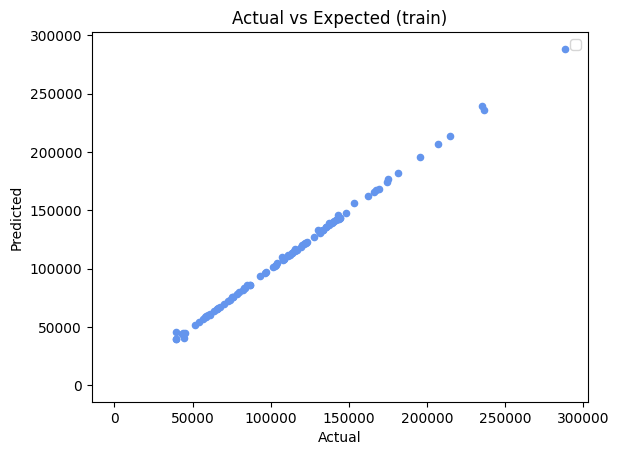

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\1774686927.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


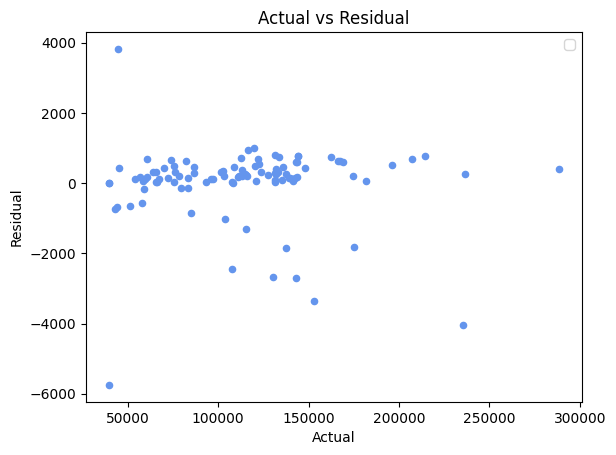

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\1774686927.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


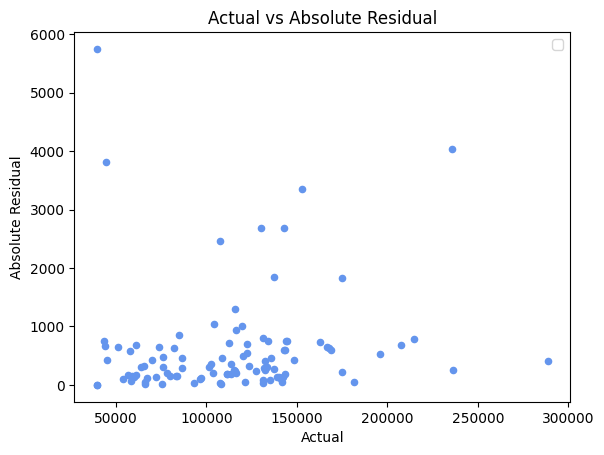

In [14]:
# Model 1 Performance Metrics
# Train Performance Metrics
mae_train = mean_absolute_error(y_true = y_train_1, y_pred = y_pred_train_1)
mape_train = mean_absolute_percentage_error(y_true = y_train_1, y_pred = y_pred_train_1) 
rmse_train = root_mean_squared_error(y_true = y_train_1, y_pred = y_pred_train_1) 
r2_train = r2_score(y_true = y_train_1, y_pred = y_pred_train_1)

print("MAE - Train:", mae_train) 
print("MAPE - Train:", mape_train) 
print("RMSE - Train:", rmse_train)
print("R2 - Train:", r2_train)

# Actual vs Expected Plots

plt.figure()
plt.scatter(y_train_1, y_pred_train_1, s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected (train)")
plt.plot([0, 0], [250, 250], 'k-')
plt.legend()
plt.show()

# Residual Analysis
  # Train Residuals
Y_train_res = pd.DataFrame(y_actl_1).reset_index(drop=True)
Y_train_pred = pd.DataFrame(y_pred_train_1).reset_index(drop=True)
Y_train_res['pred'] = Y_train_pred[0]
Y_train_res['res'] = Y_train_res['price_curr'] - Y_train_res['pred']
Y_train_res['abs_res'] = abs(Y_train_res['res'])
train_res = pd.concat([Y_train_res, X_train_1.reset_index(drop=True)], axis=1)

  # Plots
plt.figure()
plt.scatter(train_res['price_curr'], train_res['res'], s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Actual vs Residual")
plt.legend()
plt.show()

  # Plots
plt.figure()
plt.scatter(train_res['price_curr'], train_res['abs_res'], s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Absolute Residual")
plt.title("Actual vs Absolute Residual")
plt.legend()
plt.show()

## Game 2 Pricing Model

In [15]:
# Model 2
model_obj_2 = LinearRegression(fit_intercept = False).fit(X_train_2, y_train_2)
print(OLS(y_train_2, X_train_2).fit().summary())

# Train Pred
y_pred_train_2 = model_obj_2.predict(X_train_2)

# Bounded to lower limit
y_pred_train_2 = np.maximum(y_pred_train_2, lower_bound)

                                 OLS Regression Results                                
Dep. Variable:             price_curr   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          7.764e+05
Date:                Sun, 01 Jun 2025   Prob (F-statistic):                   2.11e-208
Time:                        21:18:13   Log-Likelihood:                         -832.41
No. Observations:                 101   AIC:                                      1669.
Df Residuals:                      99   BIC:                                      1674.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

MAE - Train: 573.5353229506344
MAPE - Train: 0.00567467170497491
RMSE - Train: 916.6545005559864
R2 - Train: 0.9994281036554111


C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\4269216710.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


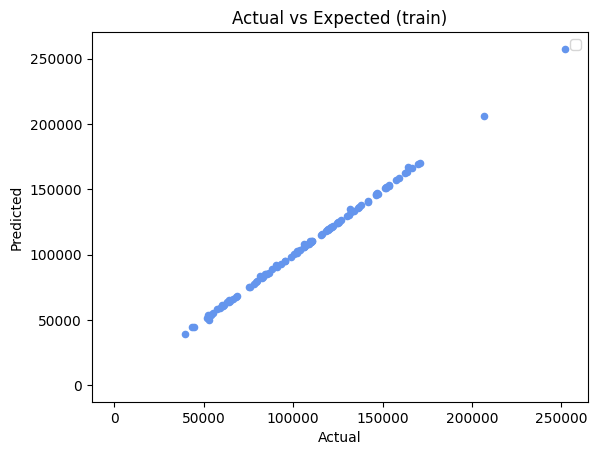

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\4269216710.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


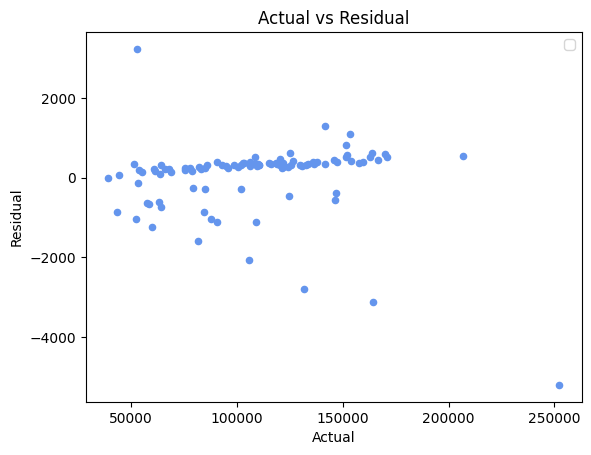

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\4269216710.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


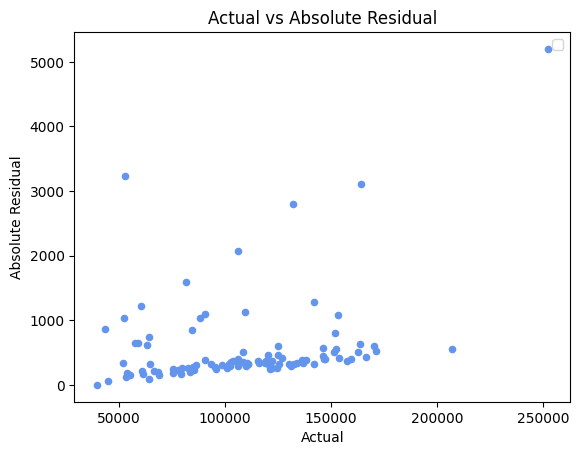

In [16]:
# Model 2 Performance Metrics
# Train Performance Metrics
mae_train = mean_absolute_error(y_true = y_train_2, y_pred = y_pred_train_2)
mape_train = mean_absolute_percentage_error(y_true = y_train_2, y_pred = y_pred_train_2) 
rmse_train = root_mean_squared_error(y_true = y_train_2, y_pred = y_pred_train_2) 
r2_train = r2_score(y_true = y_train_2, y_pred = y_pred_train_2)

print("MAE - Train:", mae_train) 
print("MAPE - Train:", mape_train) 
print("RMSE - Train:", rmse_train)
print("R2 - Train:", r2_train)

# Actual vs Expected Plots

plt.figure()
plt.scatter(y_train_2, y_pred_train_2, s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected (train)")
plt.plot([0, 0], [250, 250], 'k-')
plt.legend()
plt.show()

# Residual Analysis
  # Train Residuals
Y_train_res = pd.DataFrame(y_actl_2).reset_index(drop=True)
Y_train_pred = pd.DataFrame(y_pred_train_2).reset_index(drop=True)
Y_train_res['pred'] = Y_train_pred[0]
Y_train_res['res'] = Y_train_res['price_curr'] - Y_train_res['pred']
Y_train_res['abs_res'] = abs(Y_train_res['res'])
train_res = pd.concat([Y_train_res, X_train_1.reset_index(drop=True)], axis=1)

  # Plots
plt.figure()
plt.scatter(train_res['price_curr'], train_res['res'], s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Actual vs Residual")
plt.legend()
plt.show()

  # Plots
plt.figure()
plt.scatter(train_res['price_curr'], train_res['abs_res'], s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Absolute Residual")
plt.title("Actual vs Absolute Residual")
plt.legend()
plt.show()

## Game 3+ Pricing Model

In [17]:
# Model 3
model_obj_3 = LinearRegression(fit_intercept = True).fit(X_train_3, y_train_3)
print(OLS(y_train_3, X_train_3).fit().summary())

# Train Pred
y_pred_train_3 = model_obj_3.predict(X_train_3)

# Bounded to lower limit
y_pred_train_3 = np.maximum(y_pred_train_3, lower_bound)

                                 OLS Regression Results                                
Dep. Variable:             price_curr   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          4.166e+05
Date:                Sun, 01 Jun 2025   Prob (F-statistic):                        0.00
Time:                        21:18:14   Log-Likelihood:                         -4711.0
No. Observations:                 498   AIC:                                      9426.
Df Residuals:                     496   BIC:                                      9434.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

MAE - Train: 1561.5609574295754
MAPE - Train: 0.012712504141597705
RMSE - Train: 3079.460246311532
R2 - Train: 0.9942275798746382


C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\1579730384.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


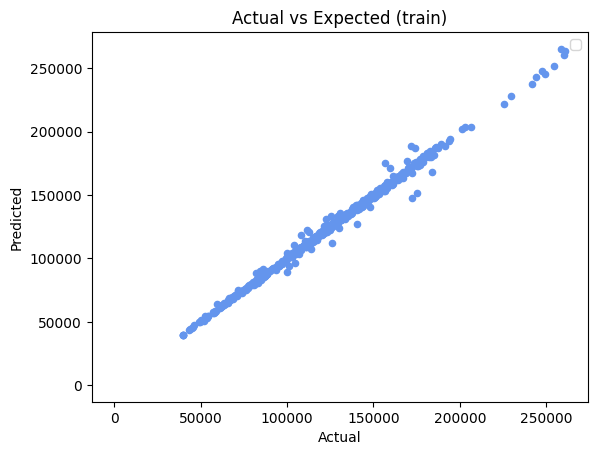

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\1579730384.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


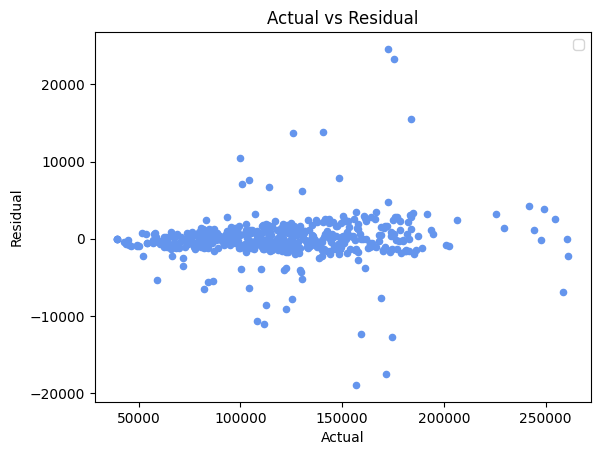

C:\Users\dilan\AppData\Local\Temp\ipykernel_2180\1579730384.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


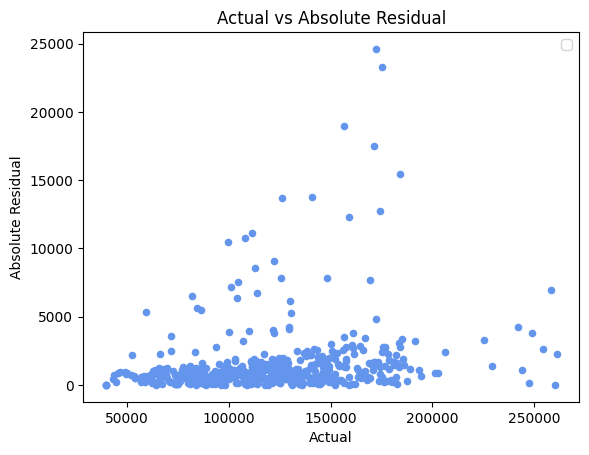

In [18]:
# Model 3 Performance Metrics
# Train Performance Metrics
mae_train = mean_absolute_error(y_true = y_train_3, y_pred = y_pred_train_3)
mape_train = mean_absolute_percentage_error(y_true = y_train_3, y_pred = y_pred_train_3) 
rmse_train = root_mean_squared_error(y_true = y_train_3, y_pred = y_pred_train_3) 
r2_train = r2_score(y_true = y_train_3, y_pred = y_pred_train_3)

print("MAE - Train:", mae_train) 
print("MAPE - Train:", mape_train) 
print("RMSE - Train:", rmse_train)
print("R2 - Train:", r2_train)

# Actual vs Expected Plots

plt.figure()
plt.scatter(y_train_3, y_pred_train_3, s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected (train)")
plt.plot([0, 0], [250, 250], 'k-')
plt.legend()
plt.show()

# Residual Analysis
  # Train Residuals
Y_train_res = pd.DataFrame(y_actl_3).reset_index(drop=True)
Y_train_pred = pd.DataFrame(y_pred_train_3).reset_index(drop=True)
Y_train_res['pred'] = Y_train_pred[0]
Y_train_res['res'] = Y_train_res['price_curr'] - Y_train_res['pred']
Y_train_res['abs_res'] = abs(Y_train_res['res'])
train_res = pd.concat([Y_train_res, X_train_1.reset_index(drop=True)], axis=1)

  # Plots
plt.figure()
plt.scatter(train_res['price_curr'], train_res['res'], s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Actual vs Residual")
plt.legend()
plt.show()

  # Plots
plt.figure()
plt.scatter(train_res['price_curr'], train_res['abs_res'], s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Absolute Residual")
plt.title("Actual vs Absolute Residual")
plt.legend()
plt.show()